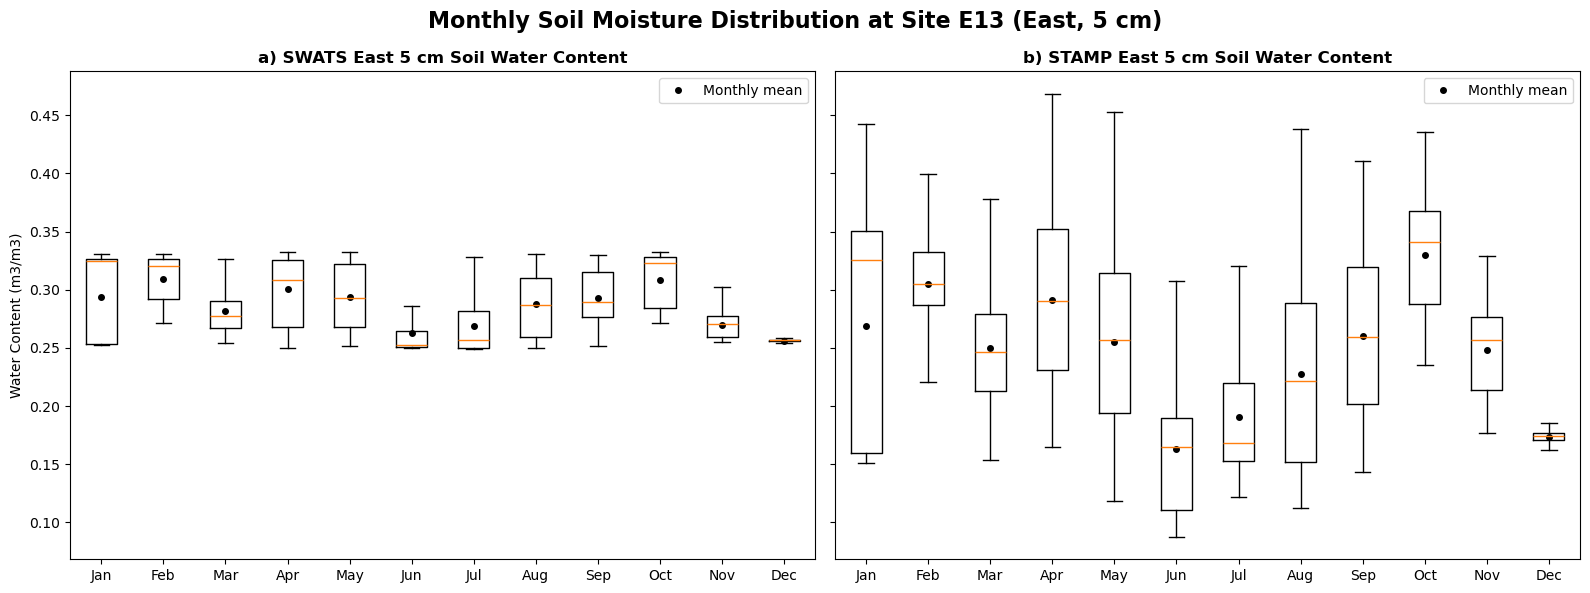

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import timedelta
from netCDF4 import Dataset, date2num, num2date
import cftime
import glob
import os
import csv
%matplotlib inline
import datetime
import matplotlib.dates as mdates
import matplotlib.dates as md
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

files_swats = sorted(glob.glob('/Users/dave121504/ARM Project/SWATS Files/sgpswats*.nc'))
swats = xr.open_mfdataset(files_swats, combine='by_coords')

files_stamp = sorted(glob.glob('/Users/dave121504/ARM Project/STAMP Files/sgpstamp*.nc'))
stamp = xr.open_mfdataset(files_stamp, combine='by_coords')


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# =========================
# SWATS EAST 5 cm
# =========================
swats_5 = swats['watcont_e'].isel(depth=0)

df_swats = swats_5.to_dataframe(name='moisture').reset_index()
df_swats['time'] = pd.to_datetime(df_swats['time'])
df_swats['month'] = df_swats['time'].dt.month
df_swats = df_swats.dropna(subset=['moisture'])

swats_monthly_data = [
    df_swats[df_swats['month'] == m]['moisture'].values
    for m in range(1, 13)
]

swats_monthly_means = [
    df_swats[df_swats['month'] == m]['moisture'].mean()
    for m in range(1, 13)
]

axes[0].boxplot(swats_monthly_data, tick_tick_labels=months, showfliers=False)
axes[0].plot(range(1, 13), swats_monthly_means, 'k.', markersize=8, label='Monthly mean')
axes[0].set_title('a) SWATS East 5 cm Soil Water Content', fontweight='bold')
axes[0].set_ylabel('Water Content (m3/m3)')
axes[0].legend()

# =========================
# STAMP EAST 5 cm
# =========================
stamp_5 = stamp['soil_specific_water_content_east'].isel(depth=0) / 100

df_stamp = stamp_5.to_dataframe(name='moisture').reset_index()
df_stamp['time'] = pd.to_datetime(df_stamp['time'])
df_stamp['month'] = df_stamp['time'].dt.month
df_stamp = df_stamp.dropna(subset=['moisture'])

stamp_monthly_data = [
    df_stamp[df_stamp['month'] == m]['moisture'].values
    for m in range(1, 13)
]

stamp_monthly_means = [
    df_stamp[df_stamp['month'] == m]['moisture'].mean()
    for m in range(1, 13)
]

axes[1].boxplot(stamp_monthly_data, tick_tick_labels=months, showfliers=False)
axes[1].plot(range(1, 13), stamp_monthly_means, 'k.', markersize=8, label='Monthly mean')
axes[1].set_title('b) STAMP East 5 cm Soil Water Content', fontweight='bold')
axes[1].legend()

fig.suptitle('Monthly Soil Moisture Distribution at Site E13 (East, 5 cm)', 
             fontsize=16, fontweight='bold')

plt.tight_layout()
#plt.savefig('boxplot_swats_stamp_east_5cm.png', dpi=300, bbox_inches='tight')
plt.show()

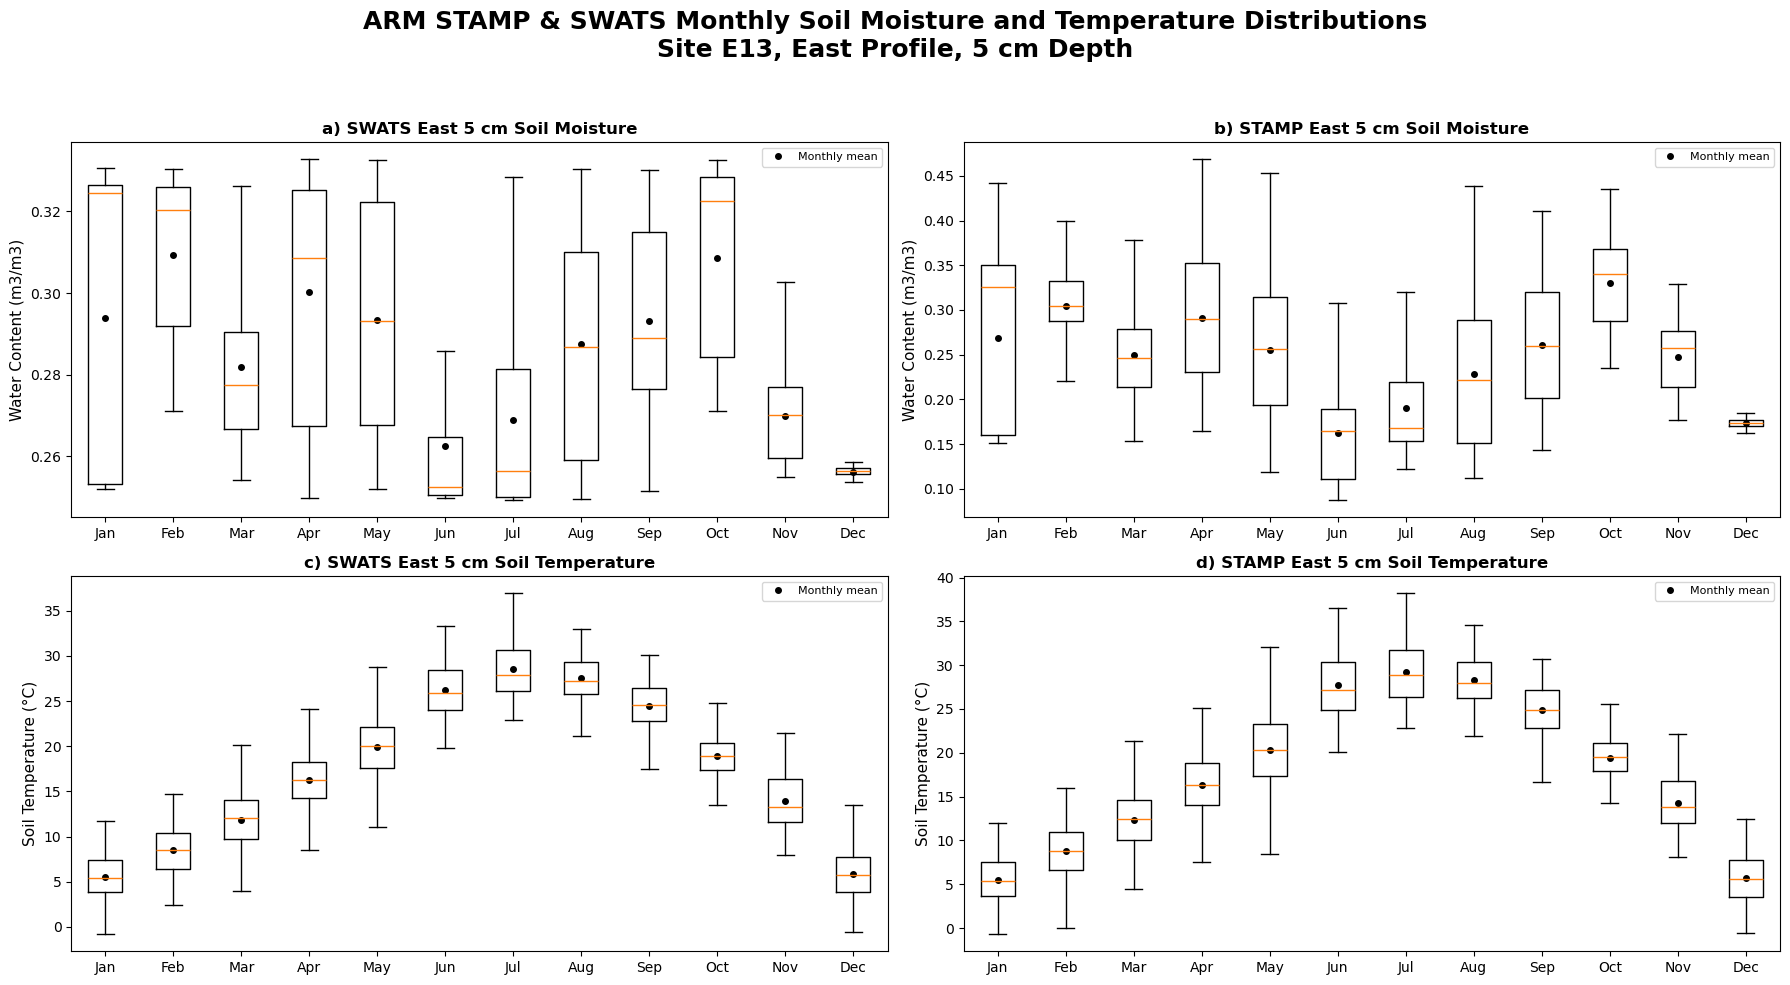

In [8]:
def make_monthly_boxplot(ax, data_array, ylabel, title, months, divide_by_100=False):
    
    # convert to dataframe
    df = data_array.to_dataframe(name='value').reset_index()
    df['time'] = pd.to_datetime(df['time'])
    
    # convert percent to decimal if needed
    if divide_by_100:
        df['value'] = df['value'] / 100
    
    # remove missing values
    df = df.dropna(subset=['value'])
    
    # get month number
    df['month'] = df['time'].dt.month
    
    # group full data by month
    monthly_data = [
        df[df['month'] == m]['value'].values
        for m in range(1, 13)
    ]
    
    # monthly mean
    monthly_means = [
        df[df['month'] == m]['value'].mean()
        for m in range(1, 13)
    ]
    
    # boxplot
    ax.boxplot(monthly_data, tick_labels=months, showfliers=False)
    
    # monthly mean dots
    ax.plot(range(1, 13), monthly_means, 'k.', markersize=8, label='Monthly mean')
    
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)


# ----------------------------
# Month labels
# ----------------------------
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# ----------------------------
# Select 5 cm East data
# ----------------------------

# Soil moisture
swats_moist_5 = swats['watcont_e'].isel(depth=0)
stamp_moist_5 = stamp['soil_specific_water_content_east'].isel(depth=0)

# Soil temperature
swats_temp_5 = swats['tsoil_e'].isel(depth=0)
stamp_temp_5 = stamp['soil_temperature_east'].isel(depth=0)

# ----------------------------
# Create figure
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# a) SWATS moisture
make_monthly_boxplot(
    axes[0, 0],
    swats_moist_5,
    ylabel='Water Content (m3/m3)',
    title='a) SWATS East 5 cm Soil Moisture',
    months=months,
    divide_by_100=False
)

# b) STAMP moisture
make_monthly_boxplot(
    axes[0, 1],
    stamp_moist_5,
    ylabel='Water Content (m3/m3)',
    title='b) STAMP East 5 cm Soil Moisture',
    months=months,
    divide_by_100=True
)

# c) SWATS temperature
make_monthly_boxplot(
    axes[1, 0],
    swats_temp_5,
    ylabel='Soil Temperature (°C)',
    title='c) SWATS East 5 cm Soil Temperature',
    months=months,
    divide_by_100=False
)

# d) STAMP temperature
make_monthly_boxplot(
    axes[1, 1],
    stamp_temp_5,
    ylabel='Soil Temperature (°C)',
    title='d) STAMP East 5 cm Soil Temperature',
    months=months,
    divide_by_100=False
)

# x-axis formatting
for ax in axes.flat:
    ax.tick_params(axis='x', labelrotation=0, labelsize=10)

fig.suptitle(
    'ARM STAMP & SWATS Monthly Soil Moisture and Temperature Distributions\n'
    'Site E13, East Profile, 5 cm Depth',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('monthly_boxplots_swats_stamp_east_5cm.png', dpi=300, bbox_inches='tight')
plt.show()

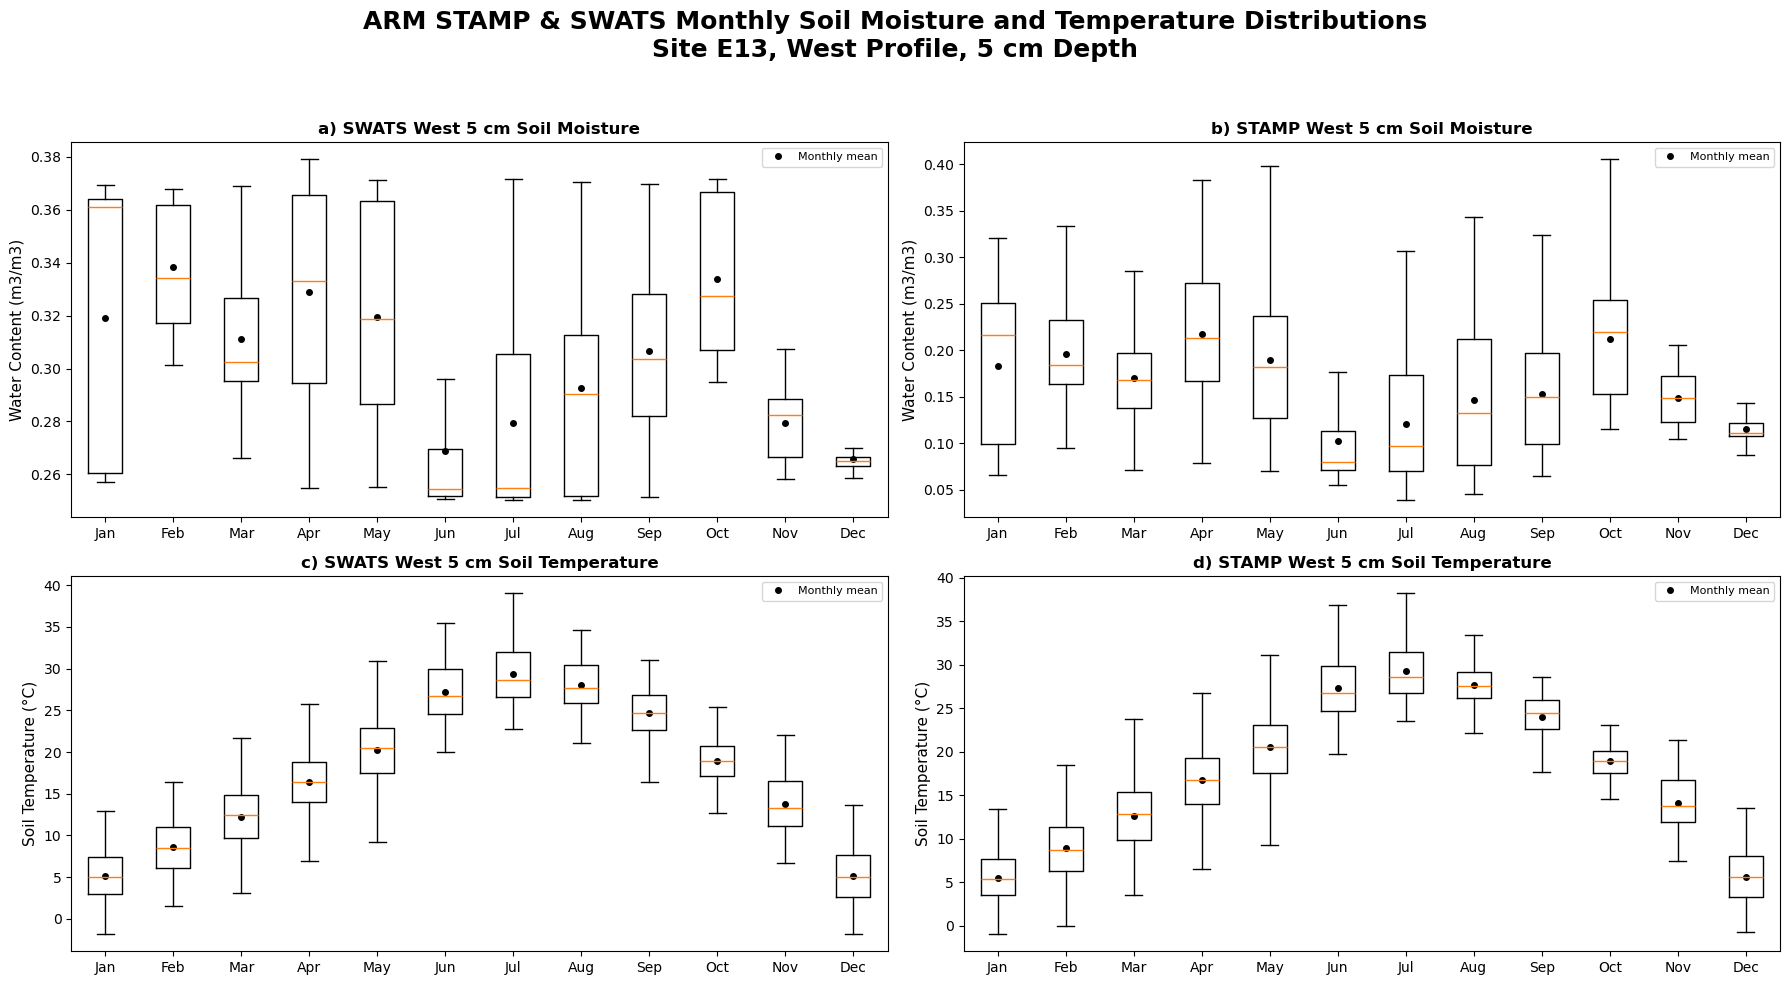

In [10]:


# ----------------------------
# Helper function
# ----------------------------
def make_monthly_boxplot(ax, data_array, ylabel, title, months, divide_by_100=False):
    
    # Convert to dataframe
    df = data_array.to_dataframe(name='value').reset_index()
    df['time'] = pd.to_datetime(df['time'])
    
    # Convert percent to decimal if needed
    if divide_by_100:
        df['value'] = df['value'] / 100
    
  
    
    # Month number
    df['month'] = df['time'].dt.month
    
    # Group all values by month
    monthly_data = [
        df[df['month'] == m]['value'].values
        for m in range(1, 13)
    ]
    
    # Monthly means
    monthly_means = [
        df[df['month'] == m]['value'].mean()
        for m in range(1, 13)
    ]
    
    # Boxplot
    ax.boxplot(monthly_data, tick_labels=months, showfliers=False)
    
    # Monthly mean dots
    ax.plot(range(1, 13), monthly_means, 'k.', markersize=8, label='Monthly mean')
    
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)


# ----------------------------
# Month labels
# ----------------------------
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# ----------------------------
# Select WEST 5 cm data
# ----------------------------

# Soil moisture
swats_moist_5 = swats['watcont_w'].isel(depth=0)
stamp_moist_5 = stamp['soil_specific_water_content_west'].isel(depth=0)

# Soil temperature
swats_temp_5 = swats['tsoil_w'].isel(depth=0)
stamp_temp_5 = stamp['soil_temperature_west'].isel(depth=0)

# ----------------------------
# Create figure
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# a) SWATS moisture
make_monthly_boxplot(
    axes[0, 0],
    swats_moist_5,
    ylabel='Water Content (m3/m3)',
    title='a) SWATS West 5 cm Soil Moisture',
    months=months,
    divide_by_100=False
)

# b) STAMP moisture
make_monthly_boxplot(
    axes[0, 1],
    stamp_moist_5,
    ylabel='Water Content (m3/m3)',
    title='b) STAMP West 5 cm Soil Moisture',
    months=months,
    divide_by_100=True
)

# c) SWATS temperature
make_monthly_boxplot(
    axes[1, 0],
    swats_temp_5,
    ylabel='Soil Temperature (°C)',
    title='c) SWATS West 5 cm Soil Temperature',
    months=months,
    divide_by_100=False
)

# d) STAMP temperature
make_monthly_boxplot(
    axes[1, 1],
    stamp_temp_5,
    ylabel='Soil Temperature (°C)',
    title='d) STAMP West 5 cm Soil Temperature',
    months=months,
    divide_by_100=False
)

for ax in axes.flat:
    ax.tick_params(axis='x', labelrotation=0, labelsize=10)

fig.suptitle(
    'ARM STAMP & SWATS Monthly Soil Moisture and Temperature Distributions\n'
    'Site E13, West Profile, 5 cm Depth',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('monthly_boxplots_swats_stamp_west_5cm.png', dpi=300, bbox_inches='tight')
plt.show()

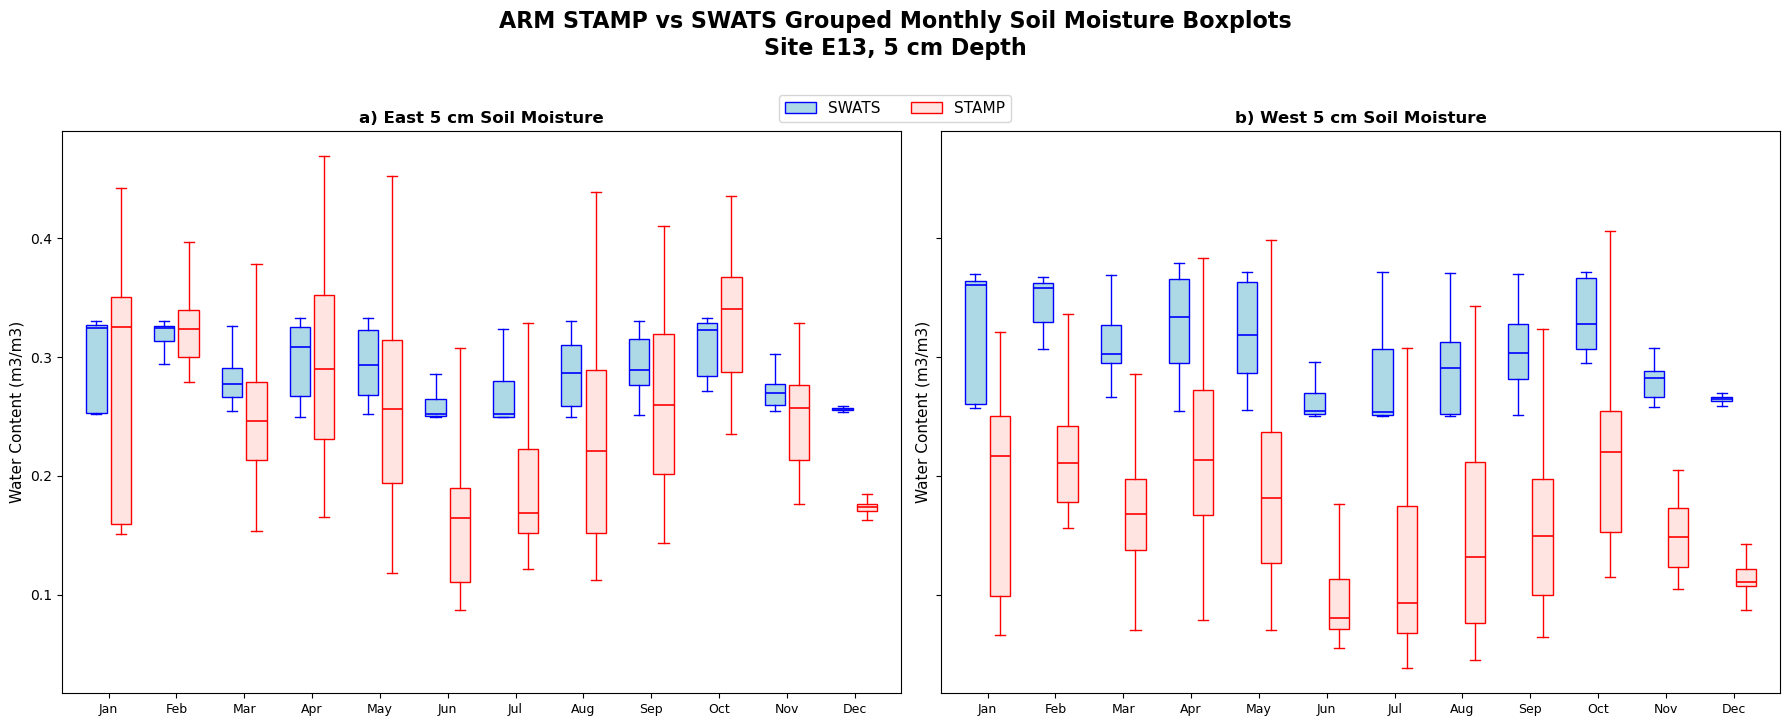

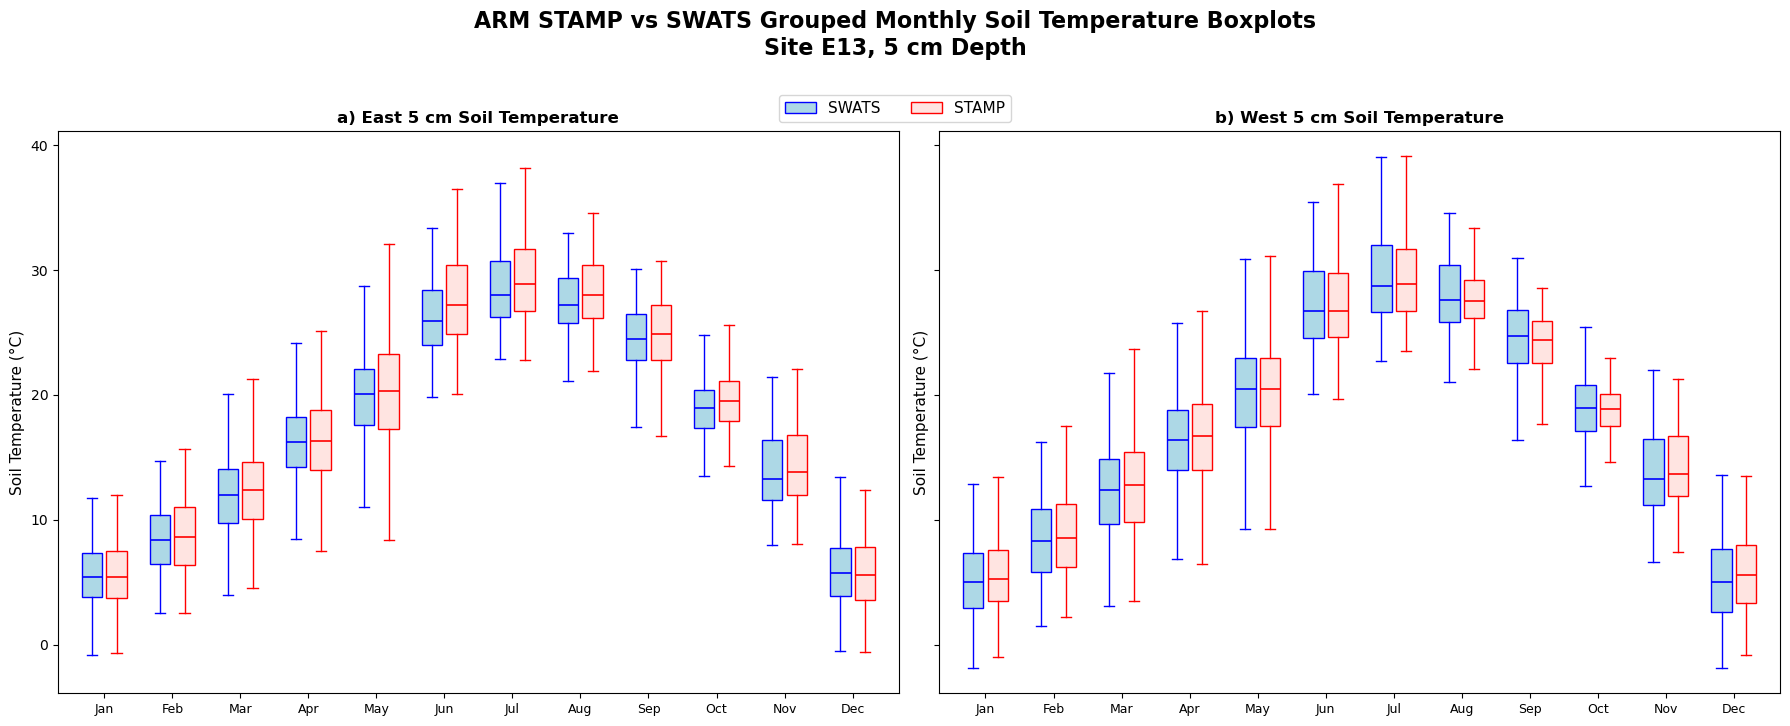

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================================================
# SETTINGS
# =========================================================
REMOVE_PARTIAL_MONTHS = True

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


# =========================================================
# HELPER FUNCTION: PREPARE MONTHLY DATA
# =========================================================
def prepare_monthly_box_data(data_array, divide_by_100=False, remove_partial_months=True):
    """
    Converts an xarray DataArray into a list of 12 arrays,
    one for each month, to use in a boxplot.
    """
    df = data_array.to_dataframe(name='value').reset_index()
    df['time'] = pd.to_datetime(df['time'])

    if divide_by_100:
        df['value'] = df['value'] / 100

    df = df.dropna(subset=['value'])

    if remove_partial_months:
        # Remove partial Feb 2016
        df = df[
            ~((df['time'] >= '2016-02-22') & (df['time'] < '2016-03-01'))
        ]

        # Remove partial Jul 2017
        df = df[
            ~((df['time'] >= '2017-07-01') & (df['time'] <= '2017-07-03'))
        ]

    df['month'] = df['time'].dt.month

    monthly_data = [
        df[df['month'] == m]['value'].values
        for m in range(1, 13)
    ]

    return monthly_data


# =========================================================
# HELPER FUNCTION: MAKE GROUPED BOXPLOT
# =========================================================
def make_grouped_boxplot(ax, swats_data, stamp_data, ylabel, title,
                         stamp_divide_by_100=False, remove_partial_months=True):

    swats_monthly = prepare_monthly_box_data(
        swats_data,
        divide_by_100=False,
        remove_partial_months=remove_partial_months
    )

    stamp_monthly = prepare_monthly_box_data(
        stamp_data,
        divide_by_100=stamp_divide_by_100,
        remove_partial_months=remove_partial_months
    )

    month_positions = np.arange(1, 13)
    swats_positions = month_positions - 0.18
    stamp_positions = month_positions + 0.18

    # SWATS boxplots
    ax.boxplot(
        swats_monthly,
        positions=swats_positions,
        widths=0.30,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='lightblue', edgecolor='blue', linewidth=1),
        medianprops=dict(color='blue', linewidth=1.2),
        whiskerprops=dict(color='blue', linewidth=1),
        capprops=dict(color='blue', linewidth=1)
    )

    # STAMP boxplots
    ax.boxplot(
        stamp_monthly,
        positions=stamp_positions,
        widths=0.30,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='mistyrose', edgecolor='red', linewidth=1),
        medianprops=dict(color='red', linewidth=1.2),
        whiskerprops=dict(color='red', linewidth=1),
        capprops=dict(color='red', linewidth=1)
    )

    ax.set_xticks(month_positions)
    ax.set_xticklabels(months)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=0, labelsize=9)


# =========================================================
# SELECT 5 cm DATA
# =========================================================

# ----- SOIL MOISTURE -----
swats_moist_E = swats['watcont_e'].isel(depth=0)
stamp_moist_E = stamp['soil_specific_water_content_east'].isel(depth=0)

swats_moist_W = swats['watcont_w'].isel(depth=0)
stamp_moist_W = stamp['soil_specific_water_content_west'].isel(depth=0)

# ----- SOIL TEMPERATURE -----
swats_temp_E = swats['tsoil_e'].isel(depth=0)
stamp_temp_E = stamp['soil_temperature_east'].isel(depth=0)

# IMPORTANT:
# If this gives an error, check the exact SWATS west temperature variable name
# using: print(swats.data_vars)
swats_temp_W = swats['tsoil_w'].isel(depth=0)
stamp_temp_W = stamp['soil_temperature_west'].isel(depth=0)


# =========================================================
# SHARED LEGEND
# =========================================================
legend_handles = [
    Patch(facecolor='lightblue', edgecolor='blue', label='SWATS'),
    Patch(facecolor='mistyrose', edgecolor='red', label='STAMP')
]


# =========================================================
# FIGURE 1: SOIL MOISTURE
# =========================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

make_grouped_boxplot(
    axes1[0],
    swats_moist_E,
    stamp_moist_E,
    ylabel='Water Content (m3/m3)',
    title='a) East 5 cm Soil Moisture',
    stamp_divide_by_100=True,
    remove_partial_months=REMOVE_PARTIAL_MONTHS
)

make_grouped_boxplot(
    axes1[1],
    swats_moist_W,
    stamp_moist_W,
    ylabel='Water Content (m3/m3)',
    title='b) West 5 cm Soil Moisture',
    stamp_divide_by_100=True,
    remove_partial_months=REMOVE_PARTIAL_MONTHS
)

fig1.legend(handles=legend_handles, loc='upper center', ncol=2, fontsize=11,
            bbox_to_anchor=(0.5, 0.92))

fig1.suptitle(
    'ARM STAMP vs SWATS Grouped Monthly Soil Moisture Boxplots\n'
    'Site E13, 5 cm Depth',
    fontsize=16,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.savefig('grouped_boxplot_soil_moisture_east_west_5cm.png',
            dpi=300, bbox_inches='tight')
plt.show()


# =========================================================
# FIGURE 2: SOIL TEMPERATURE
# =========================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

make_grouped_boxplot(
    axes2[0],
    swats_temp_E,
    stamp_temp_E,
    ylabel='Soil Temperature (°C)',
    title='a) East 5 cm Soil Temperature',
    stamp_divide_by_100=False,
    remove_partial_months=REMOVE_PARTIAL_MONTHS
)

make_grouped_boxplot(
    axes2[1],
    swats_temp_W,
    stamp_temp_W,
    ylabel='Soil Temperature (°C)',
    title='b) West 5 cm Soil Temperature',
    stamp_divide_by_100=False,
    remove_partial_months=REMOVE_PARTIAL_MONTHS
)

fig2.legend(handles=legend_handles, loc='upper center', ncol=2, fontsize=11,
            bbox_to_anchor=(0.5, 0.92))

fig2.suptitle(
    'ARM STAMP vs SWATS Grouped Monthly Soil Temperature Boxplots\n'
    'Site E13, 5 cm Depth',
    fontsize=16,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.savefig('grouped_boxplot_soil_temperature_east_west_5cm.png',dpi=300, bbox_inches='tight')
plt.show()